# ViT como Extrator Fixo — Comparação de Classificadores
## ViT Puro · ViT + VAE · ViT + kNN

### Metodologia
O backbone `extrator_VIT.keras` foi treinado previamente nos mesmos 80% do dataset CWRU.
Por isso, ele é mantido **100% congelado** em todos os experimentos — sem fine-tuning.

Isso garante:
- Representações idênticas para todos os classificadores (comparação justa)
- Métricas que refletem a capacidade discriminativa de cada **cabeça** de classificação, não do backbone
- Ausência de viés por retreino em dados já vistos

### Estrutura do notebook
```
1. Setup & dados
2. Backbone congelado → extração de features (feita UMA vez, compartilhada)
3. Modelo 1 — ViT Puro   (Dense + BN + Dropout)
4. Modelo 2 — ViT + SVAE (espaço latente supervisionado)
5. Modelo 3 — ViT + kNN  (classificação por vizinhança)
6. Comparação final
```


In [ ]:
import os, zipfile, random, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import load_model
from scipy.io import loadmat
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report)
from sklearn.manifold import TSNE

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("Ambiente configurado.")


Ambiente configurado.


## 1. Dados

In [ ]:
os.environ['KAGGLE_USERNAME'] = ""
os.environ['KAGGLE_KEY']     = ""

!kaggle datasets download -d brjapon/cwru-bearing-datasets
with zipfile.ZipFile("cwru-bearing-datasets.zip","r") as z:
    z.extractall("cwru_data")
os.remove("cwru-bearing-datasets.zip")
print("✅ Dataset extraído.")


Dataset URL: https://www.kaggle.com/datasets/brjapon/cwru-bearing-datasets
License(s): CC-BY-SA-4.0
100% 40.4M/40.4M [00:00<00:00, 134MB/s]

✅ Dataset extraído.


In [ ]:
input_folder = '/content/cwru_data/raw'
window_size  = 2048
files = [
    'B007_1_123.mat','B014_1_190.mat','B021_1_227.mat',
    'IR007_1_110.mat','IR014_1_175.mat','IR021_1_214.mat',
    'OR007_6_1_136.mat','OR014_6_1_202.mat','OR021_6_1_239.mat',
    'Time_Normal_1_098.mat'
]
CLASS_LABELS = ['B007','B014','B021','IR007','IR014',
                'IR021','OR007','OR014','OR021','Normal']

raw_samples, labels_raw = [], []
for filename in files:
    path = os.path.join(input_folder, filename)
    if not os.path.exists(path):
        print(f"Aviso: {filename} não encontrado."); continue
    mat = loadmat(path)
    key = [k for k in mat.keys() if 'DE_time' in k][0]
    signal = mat[key].flatten()
    for i in range(len(signal) // window_size):
        raw_samples.append(signal[i*window_size:(i+1)*window_size])
        labels_raw.append(filename.replace('.mat',''))

X_raw    = np.array(raw_samples)
y_labels = np.array(labels_raw)
print(f"Janelas extraídas: {len(X_raw)}")

# ── Augmentação (apenas no treino) ───────────────────────────────
def augment_signal(x, noise_std=0.02, scale_range=(0.85,1.15), shift_max=50):
    x = x + np.random.normal(0, noise_std*np.std(x), size=x.shape)
    x = x * np.random.uniform(*scale_range)
    return np.roll(x, np.random.randint(-shift_max, shift_max))

def augment_dataset(X, y, n_aug=2):
    Xl, yl = [X], [y]
    for _ in range(n_aug):
        Xl.append(np.array([augment_signal(x) for x in X])); yl.append(y)
    return np.concatenate(Xl), np.concatenate(yl)

# ── Split + normalização ─────────────────────────────────────────
le          = LabelEncoder()
y_enc       = le.fit_transform(y_labels)
num_classes = len(le.classes_)

X_train_raw, X_test_raw, y_train_base, y_test = train_test_split(
    X_raw, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc)

X_train_aug, y_train = augment_dataset(X_train_raw, y_train_base, n_aug=2)

scaler       = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_aug).reshape(-1, window_size, 1)
X_test_norm  = scaler.transform(X_test_raw).reshape(-1, window_size, 1)

print(f"Treino: {X_train_norm.shape}  |  Teste: {X_test_norm.shape}")
print(f"Classes: {CLASS_LABELS}")


Janelas extraídas: 2369
Treino: (5685, 2048, 1)  |  Teste: (474, 2048, 1)
Classes: ['B007', 'B014', 'B021', 'IR007', 'IR014', 'IR021', 'OR007', 'OR014', 'OR021', 'Normal']


## 2. Backbone congelado — extração de features

In [ ]:
# ════════════════════════════════════════════════════════════════
# O backbone é carregado e IMEDIATAMENTE congelado.
# Não há nenhum fine-tuning — trainable=False em todas as camadas.
# As features extraídas aqui são COMPARTILHADAS pelos 3 modelos.
# ════════════════════════════════════════════════════════════════
extrator = load_model("extrator_VIT.keras", compile=False)
extrator.trainable = False   # ← CONGELADO

print(f"Output do backbone: {extrator.output_shape}")
print(f"Camadas treináveis: {sum(l.trainable for l in extrator.layers)}/{len(extrator.layers)}")

def extract_features(model, X, batch_size=256):
    """Extrai features em lotes para não saturar memória."""
    parts = []
    for i in range(0, len(X), batch_size):
        parts.append(model(X[i:i+batch_size], training=False).numpy())
    return np.concatenate(parts, axis=0)

print("\nExtraindo features do conjunto de TREINO...")
X_train_feat = extract_features(extrator, X_train_norm)
print("Extraindo features do conjunto de TESTE...")
X_test_feat  = extract_features(extrator, X_test_norm)

# Normalização L2 — essencial para métricas de distância
X_train_feat_l2 = normalize(X_train_feat, norm='l2')
X_test_feat_l2  = normalize(X_test_feat,  norm='l2')

print(f"\nFeatures treino : {X_train_feat.shape}")
print(f"Features teste  : {X_test_feat.shape}")
print("Normalização L2 aplicada.")


Output do backbone: (None, 256)
Camadas treináveis: 0/13

Extraindo features do conjunto de TREINO...
Extraindo features do conjunto de TESTE...

Features treino : (5685, 256)
Features teste  : (474, 256)
Normalização L2 aplicada.


In [ ]:
# ─── Função auxiliar de t-SNE (usada pelos 3 modelos) ────────────
COLORS = plt.cm.tab10(np.linspace(0, 1, num_classes))

def plot_tsne(embeddings, y_true, y_pred, title_prefix,
              perplexity=40, n_iter=1000):
    """
    Plota dois painéis side-by-side:
      • Esquerda: pontos coloridos por classe verdadeira
      • Direita : pontos coloridos por acerto (azul) / erro (vermelho X)
    """
    print(f"Calculando t-SNE para {title_prefix}...")
    tsne = TSNE(n_components=2, random_state=SEED,
                perplexity=perplexity, n_iter=n_iter,
                learning_rate='auto', init='pca')
    z2d = tsne.fit_transform(embeddings)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"t-SNE — {title_prefix}", fontsize=13, y=1.01)

    # Painel esquerdo: classes verdadeiras
    for i, (label, color) in enumerate(zip(CLASS_LABELS, COLORS)):
        mask = (y_true == i)
        axes[0].scatter(z2d[mask,0], z2d[mask,1],
                        c=[color], label=label, alpha=0.7, s=18, edgecolors='none')
    axes[0].set_title("Por classe verdadeira")
    axes[0].legend(fontsize=7, markerscale=1.5,
                   loc='upper right', framealpha=0.7)

    # Painel direito: acertos vs erros
    correct = (y_pred == y_true)
    axes[1].scatter(z2d[correct,0],  z2d[correct,1],
                    c='#1565C0', alpha=0.45, s=14,
                    label=f'Correto ({correct.sum()})', edgecolors='none')
    axes[1].scatter(z2d[~correct,0], z2d[~correct,1],
                    c='#D32F2F', alpha=0.95, s=40,
                    label=f'Incorreto ({(~correct).sum()})',
                    marker='X', edgecolors='none')
    axes[1].set_title("Acertos vs erros")
    axes[1].legend(fontsize=9)

    for ax in axes:
        ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
        ax.tick_params(labelsize=8)
    plt.tight_layout(); plt.show()

def plot_confusion(y_true, y_pred, title, cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
    plt.figure(figsize=(11, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
                linewidths=0.4, linecolor='white')
    plt.title(title); plt.xlabel('Previsto'); plt.ylabel('Real')
    plt.tight_layout(); plt.show()
    return cm

def print_metrics(y_true, y_pred, name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred,        average='weighted', zero_division=0)
    print(f"\n{'='*48}")
    print(f"  {name}")
    print(f"{'='*48}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"{'='*48}")
    return dict(name=name, acc=acc, prec=prec, rec=rec, f1=f1)

all_results = []   # acumulador para a comparação final
print("Funções auxiliares definidas.")


Funções auxiliares definidas.


## 3. Modelo 1 — ViT Puro

Backbone congelado + cabeça Dense supervisionada.
A entrada do classificador é diretamente o vetor de features do ViT (256-d).


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ════════════════════════════════════════════════════════════════
# ViT PURO — cabeça Dense sobre features congeladas
# ════════════════════════════════════════════════════════════════
# Define a custom loss function that implements sparse categorical crossentropy with label smoothing.
# This is necessary if the installed TensorFlow/Keras version does not support `label_smoothing`
# directly in `SparseCategoricalCrossentropy`.
def create_sparse_categorical_crossentropy_with_label_smoothing(num_classes, label_smoothing=0.05):
    def sparse_crossentropy_with_smoothing(y_true, y_pred):
        # Ensure y_true is a 1D tensor of integer labels before one-hot encoding.
        # This handles cases where y_true might come in as (batch_size, 1) or even (batch_size,)
        # and ensures tf.one_hot always produces a 2D tensor (batch_size, num_classes).
        y_true_indices = tf.reshape(tf.cast(y_true, tf.int32), [-1])

        # Convert y_true to one-hot encoding.
        y_true_one_hot = tf.one_hot(y_true_indices, num_classes)

        # Apply label smoothing.
        # This formula distributes the smoothing mass 'label_smoothing'
        # uniformly across all classes, and reduces the confidence in the true class.
        epsilon = label_smoothing / num_classes
        y_true_smoothed = y_true_one_hot * (1 - label_smoothing) + epsilon

        # Calculate categorical crossentropy.
        # y_pred are probabilities (softmax output) from the model.
        loss = keras.losses.categorical_crossentropy(y_true_smoothed, y_pred, from_logits=False)
        return tf.reduce_mean(loss)
    return sparse_crossentropy_with_smoothing

def build_vit_puro(extractor_model, num_classes):
    extractor_model.trainable = False          # garante congelamento

    inputs   = extractor_model.input
    features = extractor_model.output          # (None, 256)

    x = layers.Dense(256, activation='gelu', name='p_fc1')(features)
    x = layers.BatchNormalization(name='p_bn1')(x)
    x = layers.Dropout(0.4, name='p_drop1')(x)
    x = layers.Dense(128, activation='gelu', name='p_fc2')(x)
    x = layers.BatchNormalization(name='p_bn2')(x)
    x = layers.Dropout(0.3, name='p_drop2')(x)
    out = layers.Dense(num_classes, activation='softmax', name='p_out')(x)

    model = keras.Model(inputs, out, name="ViT_Puro")
    model.compile(
        optimizer=keras.optimizers.Adam(5e-4),
        # Use the custom loss function instead of the built-in one with label_smoothing
        loss=create_sparse_categorical_crossentropy_with_label_smoothing(num_classes=num_classes, label_smoothing=0.05),
        metrics=['accuracy']
    )
    return model

model_puro = build_vit_puro(extrator, num_classes)

treinaveis = sum(p.numpy().size for p in model_puro.trainable_variables)
total      = sum(p.numpy().size for p in model_puro.variables)
print(f"Parâmetros treináveis : {treinaveis:,}  ({100*treinaveis/total:.1f}% do total)")

callbacks_puro = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint(
        'best_vit_puro.keras', monitor='val_accuracy',
        save_best_only=True, verbose=0)
]

history_puro = model_puro.fit(
    X_train_norm, y_train,
    epochs=150, batch_size=64,
    validation_split=0.15, shuffle=True,
    callbacks=callbacks_puro, verbose=1
)

Parâmetros treináveis : 100,746  (37.0% do total)
Epoch 1/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9356 - loss: 0.5318 - val_accuracy: 0.9883 - val_loss: 0.3641 - learning_rate: 5.0000e-04
Epoch 2/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9936 - loss: 0.3695 - val_accuracy: 0.9894 - val_loss: 0.3232 - learning_rate: 5.0000e-04
Epoch 3/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9928 - loss: 0.3603 - val_accuracy: 0.9965 - val_loss: 0.3063 - learning_rate: 5.0000e-04
Epoch 4/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9959 - loss: 0.3517 - val_accuracy: 0.9953 - val_loss: 0.3072 - learning_rate: 5.0000e-04
Epoch 5/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9942 - loss: 0.3468 - val_accuracy: 0.9965 - val_loss: 0.3065 - learning_rate: 5.0000e-04
Epoch 6/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9952 - loss: 0.3426 - val_accuracy: 0.9965 - val_loss: 0.3068 - learning_rate: 5.0000e-04
Epoch 7/150
76/76

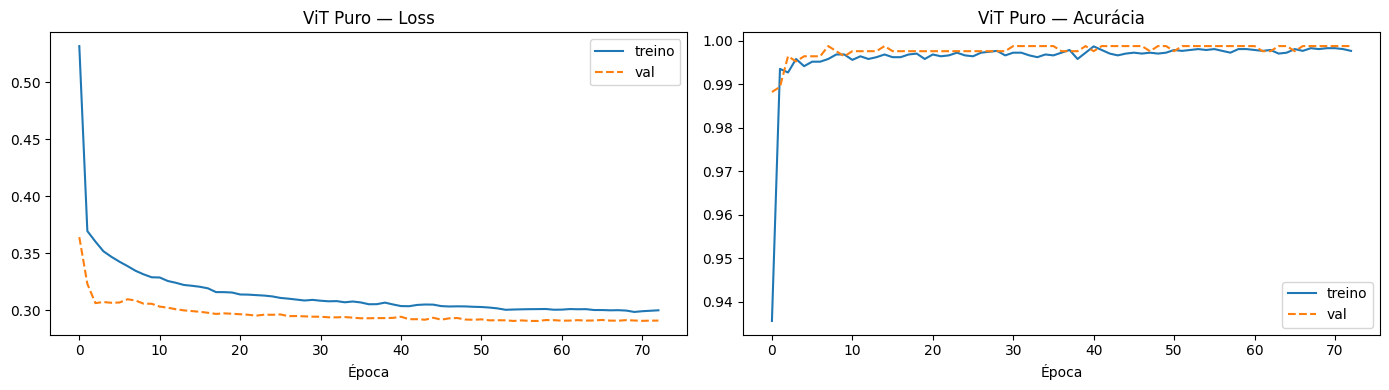

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step

  ViT Puro
  Accuracy  : 0.9895
  Precision : 0.9898
  Recall    : 0.9895
  F1 Score  : 0.9894


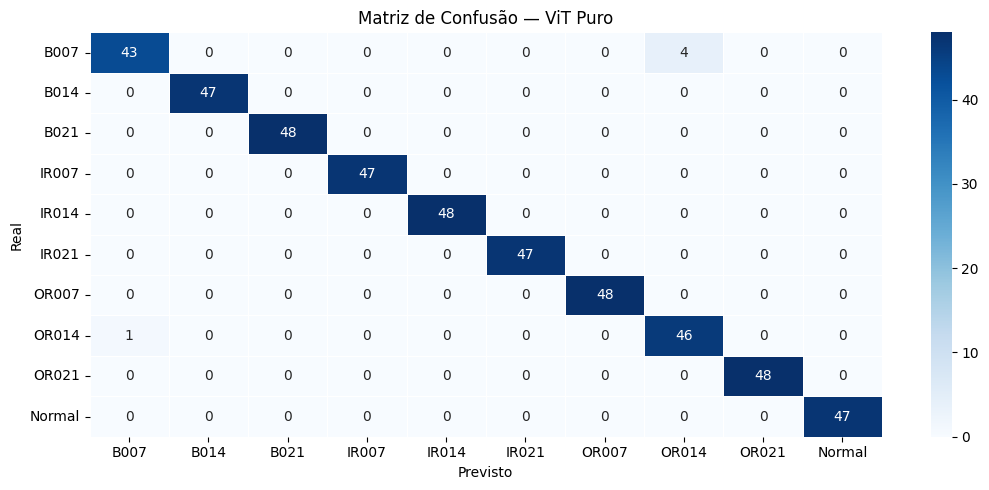

Calculando t-SNE para ViT Puro — espaço de features (backbone)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


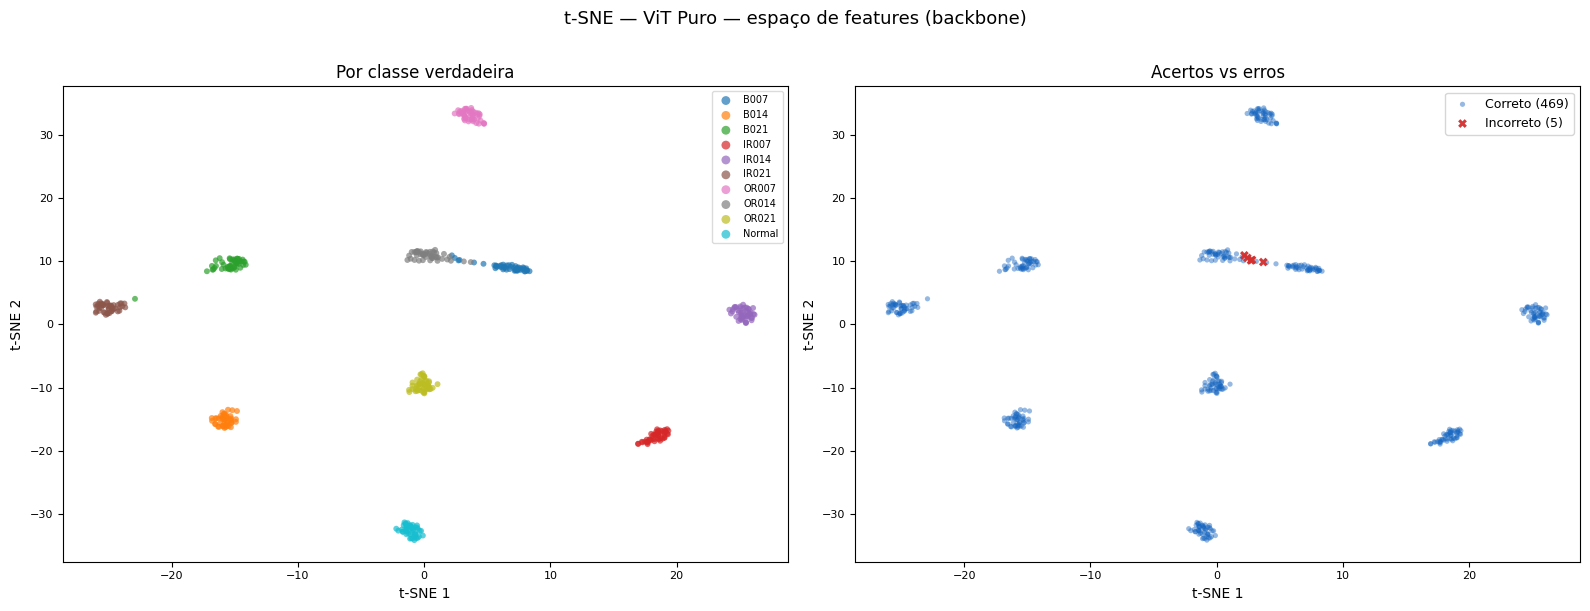

In [ ]:
# ── Curvas de treinamento ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_puro.history['loss'],         label='treino')
axes[0].plot(history_puro.history['val_loss'],     label='val', linestyle='--')
axes[1].plot(history_puro.history['accuracy'],     label='treino')
axes[1].plot(history_puro.history['val_accuracy'], label='val', linestyle='--')
axes[0].set_title('ViT Puro — Loss'); axes[1].set_title('ViT Puro — Acurácia')
for ax in axes: ax.legend(); ax.set_xlabel('Época')
plt.tight_layout(); plt.show()

# ── Predições e métricas ──────────────────────────────────────────
y_pred_puro = np.argmax(model_puro.predict(X_test_norm), axis=1)
res_puro = print_metrics(y_test, y_pred_puro, "ViT Puro")
all_results.append(res_puro)

plot_confusion(y_test, y_pred_puro,
               'Matriz de Confusão — ViT Puro', cmap='Blues')

# ── t-SNE sobre features do backbone ─────────────────────────────
# (backbone congelado → features são as mesmas para ViT Puro e kNN)
plot_tsne(X_test_feat_l2, y_test, y_pred_puro,
          title_prefix="ViT Puro — espaço de features (backbone)")


## 4. Modelo 2 — ViT + VAE

O backbone congelado projeta o sinal para um vetor de features (256-d).
O SVAE recebe essas features, aprende um espaço latente supervisionado
com perdas de reconstrução, KL, center e triplet.
O t-SNE aqui é sobre o **espaço latente z_mean** — diferente do backbone.


In [ ]:
class SupervisedVAE(keras.Model):
    def __init__(self, extractor_model_path, latent_dim, num_classes,
                 beta=0.01, gamma=5.0,
                 lambda_center=0.10,
                 lambda_triplet=0.05,
                 triplet_margin=1.0,
                 **kwargs):
        super().__init__(**kwargs)
        self.latent_dim     = latent_dim
        self.num_classes    = num_classes
        self.beta           = beta
        self.gamma          = gamma
        self.lambda_center  = lambda_center
        self.lambda_triplet = lambda_triplet
        self.triplet_margin = triplet_margin
        self.extractor_model_path = extractor_model_path

        # Centros de classe aprendíveis (center loss)
        self.centers = self.add_weight(
            name="class_centers", shape=(num_classes, latent_dim),
            initializer="glorot_uniform", trainable=True)

        # Backbone CONGELADO - Carrega o modelo a partir do caminho do arquivo
        self.encoder_net = keras.models.load_model(self.extractor_model_path, compile=False)
        self.encoder_net.trainable = False

        # Projeção para espaço latente
        self.z_mean    = layers.Dense(latent_dim, name="z_mean")
        self.z_log_var = layers.Dense(latent_dim, name="z_log_var")

        # Decoder — reconstrói o sinal original (2048, 1)
        self.decoder_net = keras.Sequential([
            layers.Input(shape=(latent_dim,)),
            layers.Dense(64*64, activation='gelu'),
            layers.Reshape((64, 64)),
            layers.Conv1DTranspose(128, 4, strides=2, padding='same', activation='gelu'),
            layers.BatchNormalization(),
            layers.Conv1DTranspose(64,  4, strides=2, padding='same', activation='gelu'),
            layers.BatchNormalization(),
            layers.Conv1DTranspose(32,  4, strides=2, padding='same', activation='gelu'),
            layers.BatchNormalization(),
            layers.Conv1DTranspose(16,  4, strides=2, padding='same', activation='gelu'),
            layers.Conv1DTranspose(1,   3, strides=2, padding='same', activation='linear') # Adicionado strides=2
        ], name="decoder")

        # Classificador sobre z_mean
        self.classifier = keras.Sequential([
            layers.Input(shape=(latent_dim,)),
            layers.Dense(256, activation='gelu'),
            layers.BatchNormalization(),
            layers.Dropout(0.4),
            layers.Dense(128, activation='gelu'),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(num_classes, activation='softmax')
        ], name="classifier")

    def encode(self, x):
        h = self.encoder_net(x, training=False)   # backbone sempre em inferência
        return self.z_mean(h), self.z_log_var(h)

    def reparameterize(self, z_mean, z_log_var):
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

    def call(self, x, training=False):
        z_mean, z_log_var = self.encode(x)
        z       = self.reparameterize(z_mean, z_log_var)
        x_recon = self.decoder_net(z)
        logits  = self.classifier(z_mean, training=training)
        return x_recon, z_mean, z_log_var, logits

    def compute_triplet_loss(self, z, y):
        y = tf.cast(y, tf.int32)
        z = tf.math.l2_normalize(z, axis=1)
        diff  = tf.expand_dims(z,1) - tf.expand_dims(z,0)
        dist  = tf.sqrt(tf.reduce_sum(tf.square(diff), axis=2) + 1e-12)
        eq    = tf.equal(tf.expand_dims(y,1), tf.expand_dims(y,0))
        m_pos = tf.cast(eq, tf.float32) * (1.0 - tf.eye(tf.shape(y)[0]))
        m_neg = 1.0 - tf.cast(eq, tf.float32)
        hp    = tf.reduce_max(dist * m_pos, axis=1)
        hn    = tf.reduce_min(dist + (tf.reduce_max(dist)+1.0)*(1.0-m_neg), axis=1)
        valid = tf.reduce_sum(m_pos, axis=1) > 0
        loss  = tf.boolean_mask(tf.maximum(hp - hn + self.triplet_margin, 0.0), valid)
        return tf.cond(tf.size(loss)>0,
                       lambda: tf.reduce_mean(loss),
                       lambda: tf.constant(0.0, dtype=tf.float32))

    def _all_losses(self, x, y, x_recon, z_mean, z_log_var, logits):
        rec  = tf.reduce_mean(tf.square(x - x_recon))
        kl   = tf.reduce_mean(-0.5*tf.reduce_sum(
                   1+z_log_var-tf.square(z_mean)-tf.exp(z_log_var), axis=1))
        cls  = tf.reduce_mean(
                   keras.losses.sparse_categorical_crossentropy(y, logits))
        ctr  = tf.reduce_mean(tf.reduce_sum(
                   tf.square(z_mean - tf.gather(self.centers,
                                                tf.cast(y,tf.int32))), axis=1))
        tri  = self.compute_triplet_loss(z_mean, y)
        tot  = rec + self.beta*kl + self.gamma*cls + self.lambda_center*ctr + self.lambda_triplet*tri
        return tot, rec, kl, cls, ctr, tri

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            xr, zm, zlv, logits = self(x, training=True)
            tot,rec,kl,cls,ctr,tri = self._all_losses(x,y,xr,zm,zlv,logits)
        grads, _ = tf.clip_by_global_norm(
                       tape.gradient(tot, self.trainable_weights), 1.0)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        acc = tf.reduce_mean(tf.cast(
              tf.equal(tf.argmax(logits,1), tf.cast(y,tf.int64)), tf.float32))
        return {"loss":tot,"rec_loss":rec,"kl_loss":kl,
                "class_loss":cls,"center_loss":ctr,"triplet_loss":tri,"accuracy":acc}

    def test_step(self, data):
        x, y = data
        xr, zm, zlv, logits = self(x, training=False)
        tot,rec,kl,cls,ctr,tri = self._all_losses(x,y,xr,zm,zlv,logits)
        acc = tf.reduce_mean(tf.cast(
              tf.equal(tf.argmax(logits,1), tf.cast(y,tf.int64)), tf.float32))
        return {"loss":tot,"rec_loss":rec,"kl_loss":kl,
                "class_loss":cls,"center_loss":ctr,"triplet_loss":tri,"accuracy":acc}

    def get_config(self):
        config = super().get_config()
        config.update({
            "extractor_model_path": self.extractor_model_path,
            "latent_dim": self.latent_dim,
            "num_classes": self.num_classes,
            "beta": self.beta,
            "gamma": self.gamma,
            "lambda_center": self.lambda_center,
            "lambda_triplet": self.lambda_triplet,
            "triplet_margin": self.triplet_margin,
        })
        return config

print("Classe SupervisedVAE definida.")

Classe SupervisedVAE definida.


In [ ]:
vae = SupervisedVAE(
    extractor_model_path = "extrator_VIT.keras", # Changed this to pass the file path
    latent_dim           = 64,
    num_classes          = num_classes,
    beta                 = 0.01,
    gamma                = 5.0,
    lambda_center        = 0.10,
    lambda_triplet       = 0.05,
    triplet_margin       = 1.0
)
vae.compile(optimizer=keras.optimizers.Adam(1e-3))

callbacks_vae = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint(
        'best_vit_svae.keras', monitor='val_accuracy',
        save_best_only=True, verbose=0, mode='max')
]

history_vae = vae.fit(
    X_train_norm, y_train,
    epochs=150, batch_size=64,
    validation_split=0.15, shuffle=True,
    callbacks=callbacks_vae, verbose=1
)

Epoch 1/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 43s 299ms/step - accuracy: 0.9688 - center_loss: 2.1716 - class_loss: 0.1156 - kl_loss: 2.2641 - loss: 1.7111 - rec_loss: 0.8561 - triplet_loss: 0.7434 - val_accuracy: 0.9524 - val_center_loss: 2.3070 - val_class_loss: 1.2856 - val_kl_loss: 2.3932 - val_loss: 7.6943 - val_rec_loss: 0.9821 - val_triplet_loss: 0.5920 - learning_rate: 0.0010
Epoch 2/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9688 - center_loss: 1.1746 - class_loss: 0.0753 - kl_loss: 1.7216 - loss: 1.4019 - rec_loss: 0.8561 - triplet_loss: 0.6897 - val_accuracy: 1.0000 - val_center_loss: 1.2693 - val_class_loss: 0.7691 - val_kl_loss: 1.8277 - val_loss: 4.9998 - val_rec_loss: 0.9821 - val_triplet_loss: 0.5368 - learning_rate: 0.0010
Epoch 3/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - center_loss: 0.9379 - class_loss: 0.0079 - kl_loss: 1.6225 - loss: 1.0366 - rec_loss: 0.8560 - triplet_loss: 0.6255 - val_accuracy: 1.0000 - val_center_loss: 1.0078 - va

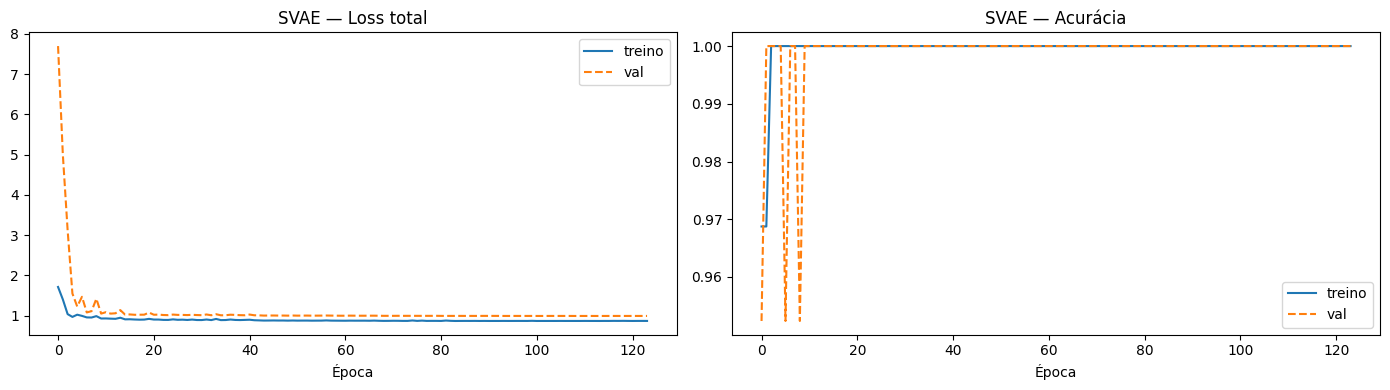

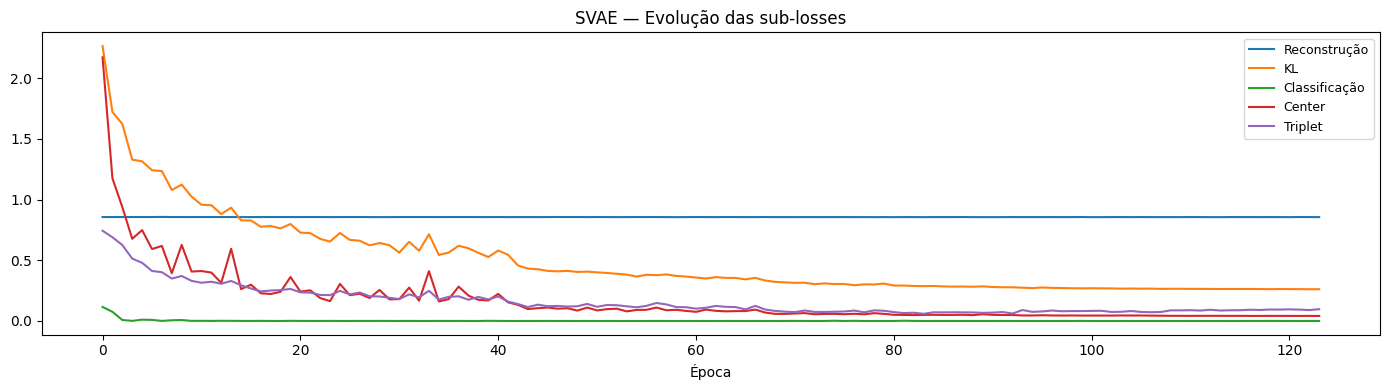


  ViT + SVAE
  Accuracy  : 0.9916
  Precision : 0.9922
  Recall    : 0.9916
  F1 Score  : 0.9915


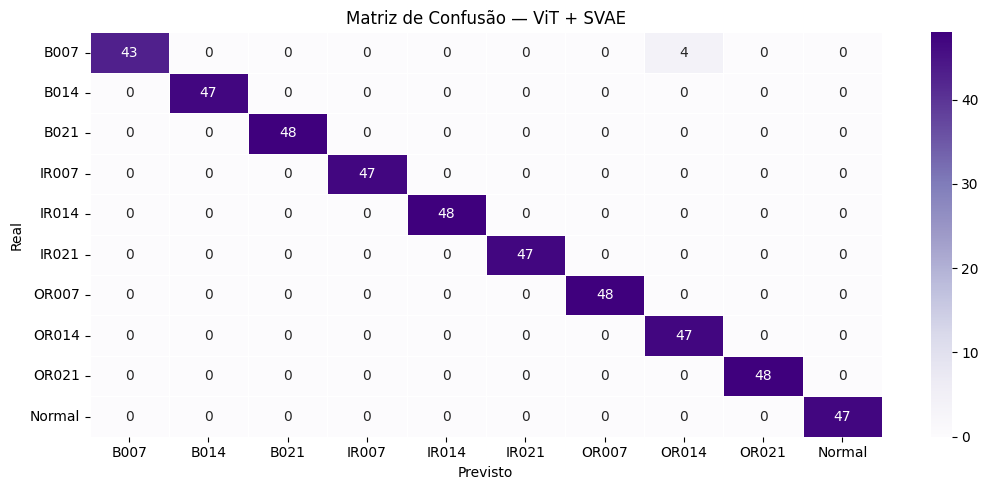

Calculando t-SNE para ViT + SVAE — espaço latente z_mean (64-d)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


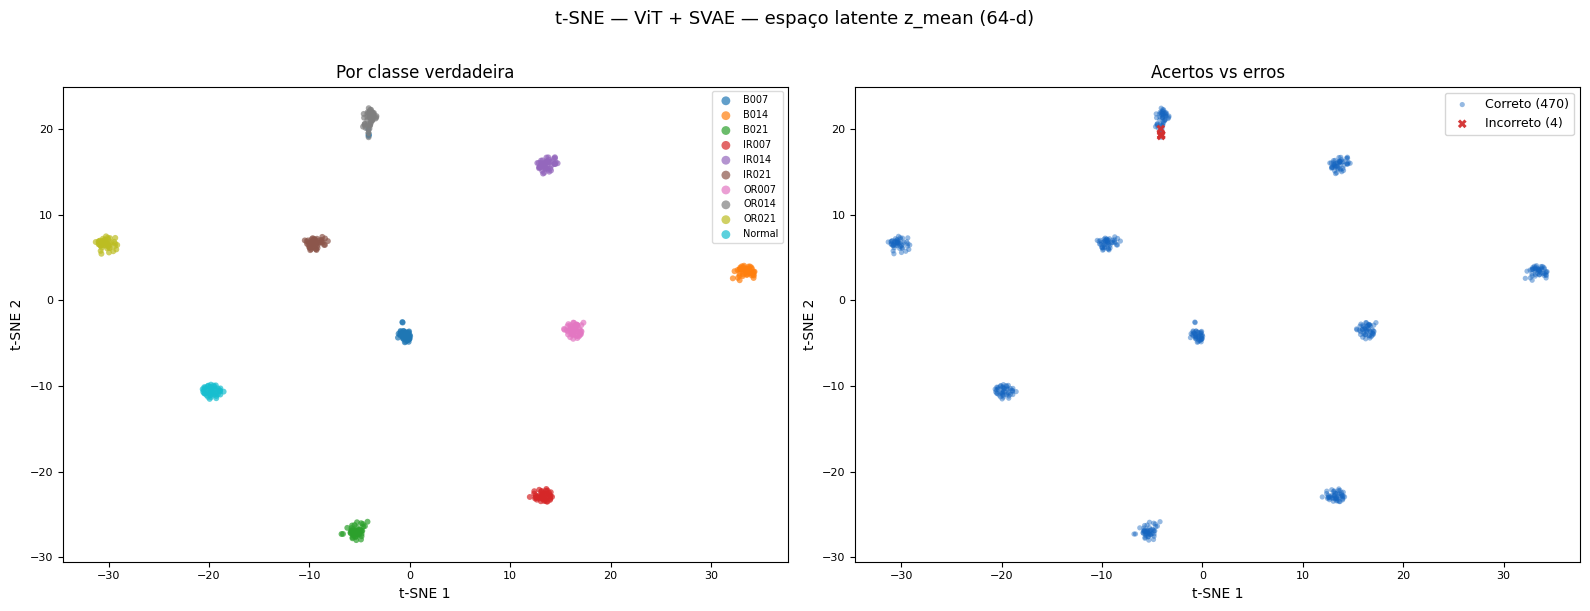

In [ ]:
# ── Curvas de treinamento ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_vae.history['loss'],         label='treino')
axes[0].plot(history_vae.history['val_loss'],     label='val', linestyle='--')
axes[1].plot(history_vae.history['accuracy'],     label='treino')
axes[1].plot(history_vae.history['val_accuracy'], label='val', linestyle='--')
axes[0].set_title('SVAE — Loss total'); axes[1].set_title('SVAE — Acurácia')
for ax in axes: ax.legend(); ax.set_xlabel('Época')
plt.tight_layout(); plt.show()

# Evolução das sub-losses
keys = ['rec_loss','kl_loss','class_loss','center_loss','triplet_loss']
labels_sub = ['Reconstrução','KL','Classificação','Center','Triplet']
fig, ax = plt.subplots(figsize=(14, 4))
for k, lbl in zip(keys, labels_sub):
    if k in history_vae.history:
        ax.plot(history_vae.history[k], label=lbl)
ax.set_title('SVAE — Evolução das sub-losses')
ax.legend(fontsize=9); ax.set_xlabel('Época')
plt.tight_layout(); plt.show()

# ── Predições e métricas ──────────────────────────────────────────
_, z_mean_test, _, logits_test = vae(X_test_norm, training=False)
y_pred_vae  = tf.argmax(logits_test, axis=1).numpy()
z_mean_np   = z_mean_test.numpy()

res_vae = print_metrics(y_test, y_pred_vae, "ViT + SVAE")
all_results.append(res_vae)

plot_confusion(y_test, y_pred_vae,
               'Matriz de Confusão — ViT + SVAE', cmap='Purples')

# ── t-SNE sobre o ESPAÇO LATENTE z_mean (não as features do backbone)
plot_tsne(z_mean_np, y_test, y_pred_vae,
          title_prefix="ViT + SVAE — espaço latente z_mean (64-d)")


## 5. Modelo 3 — ViT + kNN

O kNN recebe diretamente as features do backbone congelado (normalizadas em L2).
O k ótimo é selecionado por validação cruzada 5-fold estratificada,
testando quatro combinações de espaço de features × métrica de distância.


PCA: 256d → 7d (0.967 variância retida)

Buscando k ótimo — CV 5-fold...
  [L2 + Euclidiana]  melhor k=3  acc=0.9974
  [L2 + Coseno]  melhor k=5  acc=0.9977
  [PCA + Euclidiana]  melhor k=5  acc=0.9974
  [PCA + Coseno]  melhor k=7  acc=0.9972


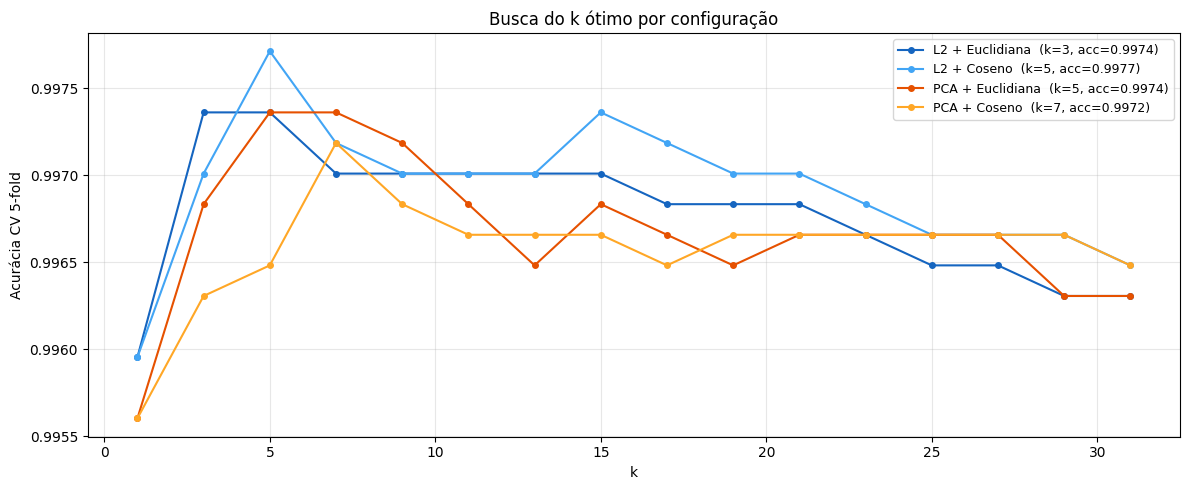


Melhor config : L2 + Coseno
k ótimo       : 5   métrica: cosine


In [ ]:
# ════════════════════════════════════════════════════════════════
# ViT + kNN — busca do k ótimo
# ════════════════════════════════════════════════════════════════
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=SEED, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_feat_l2)
X_test_pca  = pca.transform(X_test_feat_l2)
print(f"PCA: {X_train_feat_l2.shape[1]}d → {X_train_pca.shape[1]}d "
      f"({pca.explained_variance_ratio_.sum():.3f} variância retida)")

k_candidates = list(range(1, 32, 2))
configs = [
    ("L2 + Euclidiana",   X_train_feat_l2, "euclidean"),
    ("L2 + Coseno",       X_train_feat_l2, "cosine"),
    ("PCA + Euclidiana",  X_train_pca,     "euclidean"),
    ("PCA + Coseno",      X_train_pca,     "cosine"),
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results_knn = {}

print("\nBuscando k ótimo — CV 5-fold...")
for cfg_name, X_cfg, metric in configs:
    scores = []
    for k in k_candidates:
        knn_cv = KNeighborsClassifier(
            n_neighbors=k, metric=metric,
            weights='distance', algorithm='brute', n_jobs=-1)
        s = cross_val_score(knn_cv, X_cfg, y_train,
                            cv=cv, scoring='accuracy', n_jobs=-1)
        scores.append(s.mean())
    results_knn[cfg_name] = scores
    best_k_cfg = k_candidates[int(np.argmax(scores))]
    print(f"  [{cfg_name}]  melhor k={best_k_cfg}  acc={max(scores):.4f}")

# Gráfico da busca
colors_cfg = ['#1565C0','#42A5F5','#E65100','#FFA726']
plt.figure(figsize=(12, 5))
for (cfg_name, scores), c in zip(results_knn.items(), colors_cfg):
    bk = k_candidates[int(np.argmax(scores))]
    plt.plot(k_candidates, scores, marker='o', markersize=4,
             color=c, label=f"{cfg_name}  (k={bk}, acc={max(scores):.4f})")
plt.xlabel('k'); plt.ylabel('Acurácia CV 5-fold')
plt.title('Busca do k ótimo por configuração')
plt.legend(fontsize=9); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Seleciona melhor configuração
best_cfg   = max(results_knn, key=lambda c: max(results_knn[c]))
best_k_idx = int(np.argmax(results_knn[best_cfg]))
best_k     = k_candidates[best_k_idx]
best_metric = "cosine" if "Coseno" in best_cfg else "euclidean"
use_pca    = best_cfg.startswith("PCA")
X_tr_knn   = X_train_pca    if use_pca else X_train_feat_l2
X_te_knn   = X_test_pca     if use_pca else X_test_feat_l2
# Para o t-SNE usaremos sempre as features L2 (mais interpretável)
print(f"\nMelhor config : {best_cfg}")
print(f"k ótimo       : {best_k}   métrica: {best_metric}")


kNN treinado: k=5  métrica=cosine  features=L2 256d

  ViT + kNN (k=5)
  Accuracy  : 0.9895
  Precision : 0.9898
  Recall    : 0.9895
  F1 Score  : 0.9894


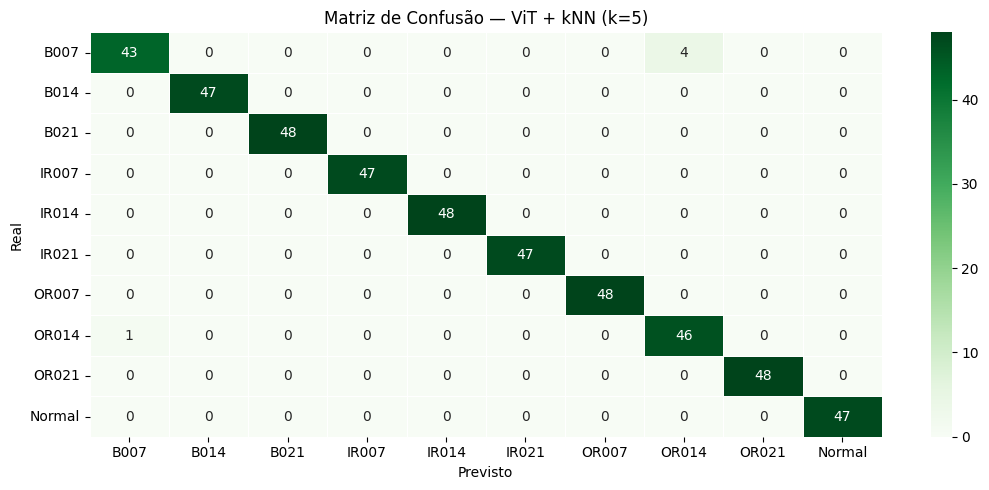

Calculando t-SNE para ViT + kNN (k=5) — espaço de features (backbone)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


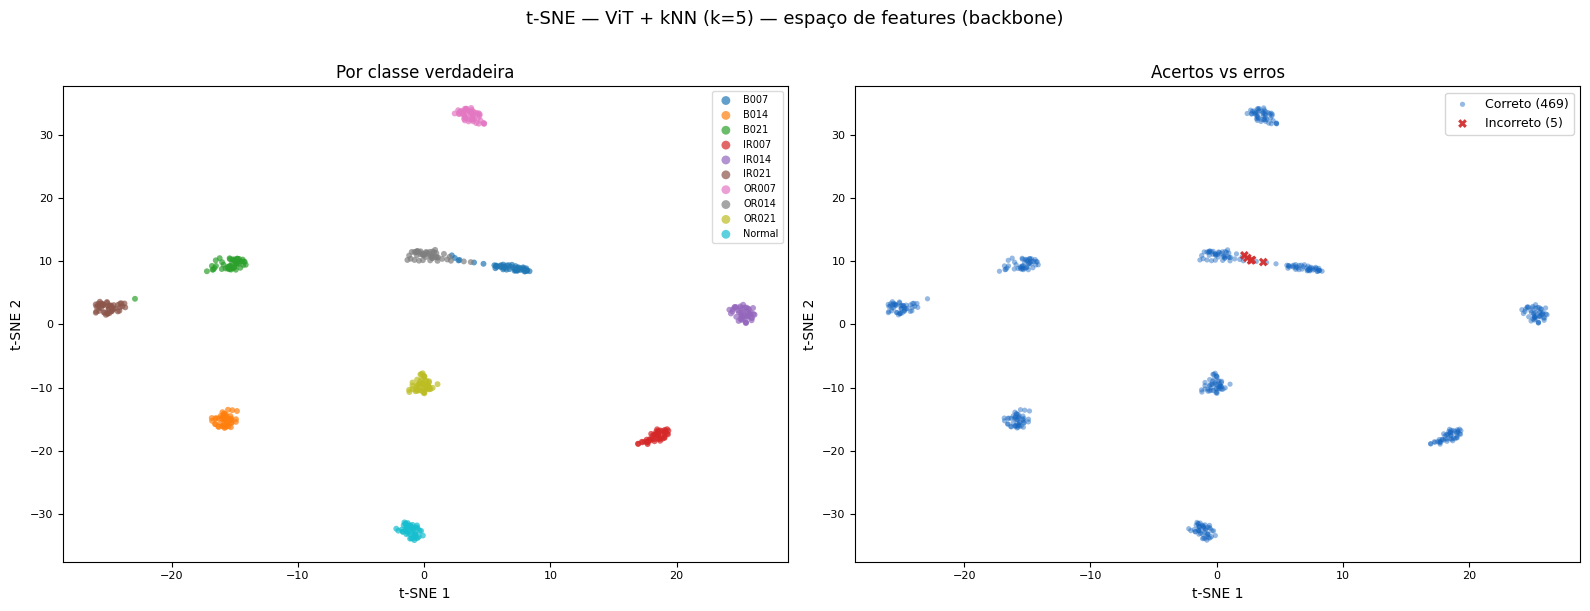

In [ ]:
# ─── Treinamento final do kNN ─────────────────────────────────────
knn_final = KNeighborsClassifier(
    n_neighbors=best_k, metric=best_metric,
    weights='distance', algorithm='brute', n_jobs=-1)
knn_final.fit(X_tr_knn, y_train)
print(f"kNN treinado: k={best_k}  métrica={best_metric}  "
      f"features={'PCA '+str(X_tr_knn.shape[1])+'d' if use_pca else 'L2 '+str(X_tr_knn.shape[1])+'d'}")

# ── Predições e métricas ──────────────────────────────────────────
y_pred_knn = knn_final.predict(X_te_knn)
res_knn = print_metrics(y_test, y_pred_knn, f"ViT + kNN (k={best_k})")
all_results.append(res_knn)

plot_confusion(y_test, y_pred_knn,
               f'Matriz de Confusão — ViT + kNN (k={best_k})', cmap='Greens')

# ── t-SNE — mesmas features do backbone, erros do kNN destacados ──
# (as features são as mesmas do ViT Puro; o que muda são os erros)
plot_tsne(X_test_feat_l2, y_test, y_pred_knn,
          title_prefix=f"ViT + kNN (k={best_k}) — espaço de features (backbone)")


## 6. Comparação final — os três modelos


  Comparação final — backbone congelado
                 Accuracy  Precision  Recall     F1
name                                               
ViT Puro           0.9895     0.9898  0.9895 0.9894
ViT + SVAE         0.9916     0.9922  0.9916 0.9915
ViT + kNN (k=5)    0.9895     0.9898  0.9895 0.9894


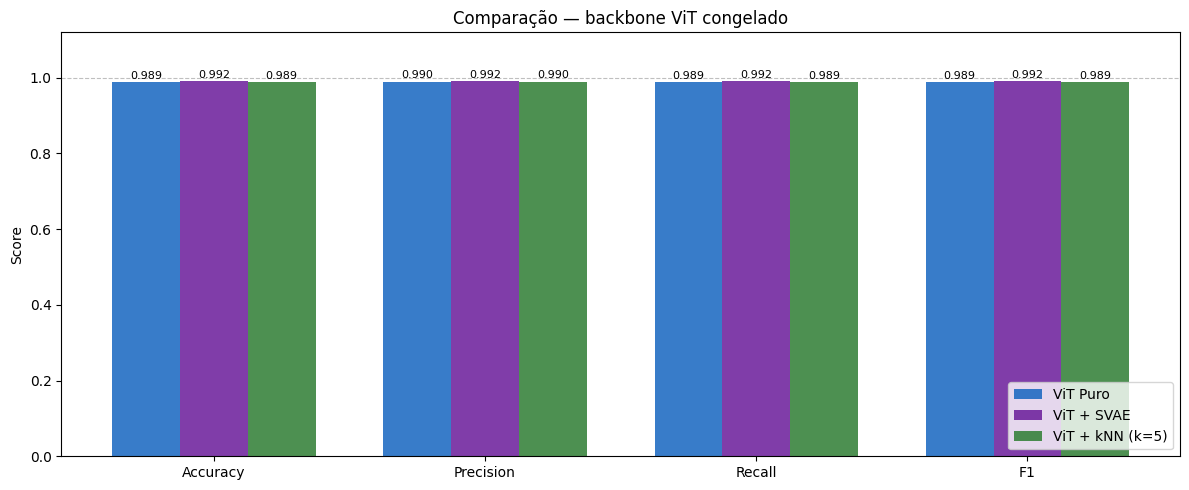


Melhor por métrica:
  Accuracy    : ViT + SVAE  (0.9916)
  Precision   : ViT + SVAE  (0.9922)
  Recall      : ViT + SVAE  (0.9916)
  F1          : ViT + SVAE  (0.9915)


In [ ]:
# ════════════════════════════════════════════════════════════════
# Tabela e gráfico comparativo
# ════════════════════════════════════════════════════════════════
import pandas as pd

df = pd.DataFrame(all_results).set_index('name')
df.columns = ['Accuracy','Precision','Recall','F1']
print("\n" + "="*55)
print("  Comparação final — backbone congelado")
print("="*55)
print(df.to_string(float_format=lambda x: f"{x:.4f}"))
print("="*55)

# Gráfico de barras agrupadas
metrics  = ['Accuracy','Precision','Recall','F1']
models   = df.index.tolist()
x        = np.arange(len(metrics))
width    = 0.25
colors_bar = ['#1565C0','#6A1B9A','#2E7D32']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model, color) in enumerate(zip(models, colors_bar)):
    vals = [df.loc[model, m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=model,
                  color=color, alpha=0.85, edgecolor='none')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score'); ax.set_title('Comparação — backbone ViT congelado')
ax.legend(loc='lower right')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout(); plt.show()

# Destaca o melhor em cada métrica
print("\nMelhor por métrica:")
for m in metrics:
    best = df[m].idxmax()
    print(f"  {m:12s}: {best}  ({df.loc[best,m]:.4f})")


## Painel comparativo — erros dos três modelos no mesmo espaço

O t-SNE abaixo usa o **mesmo espaço** (features do backbone, L2) para os três modelos,
permitindo comparar visualmente quais regiões cada classificador erra.


Calculando t-SNE para o painel comparativo...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


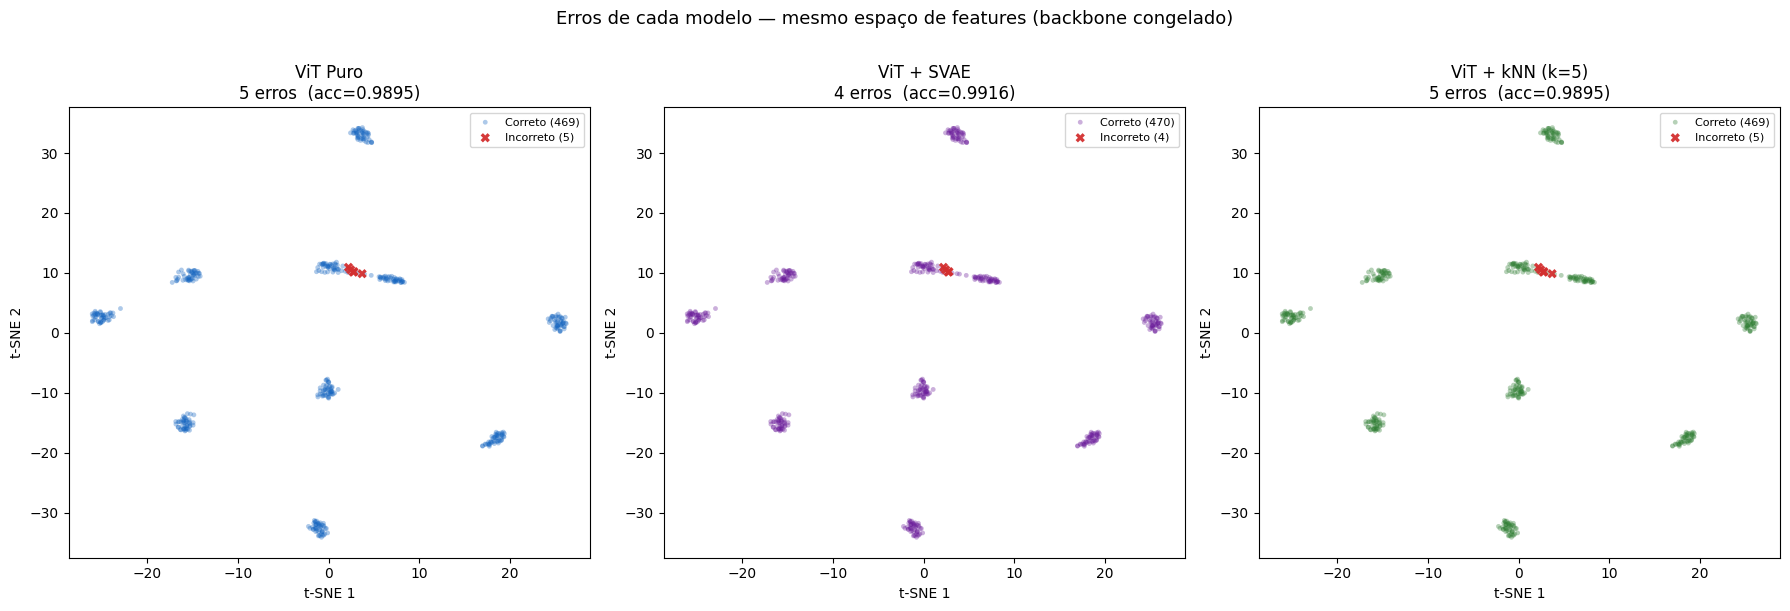

In [ ]:
print("Calculando t-SNE para o painel comparativo...")
tsne_shared = TSNE(n_components=2, random_state=SEED,
                   perplexity=40, n_iter=1000,
                   learning_rate='auto', init='pca')
z_shared = tsne_shared.fit_transform(X_test_feat_l2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Erros de cada modelo — mesmo espaço de features (backbone congelado)",
             fontsize=13, y=1.01)

for ax, y_pred, title, color in zip(
    axes,
    [y_pred_puro,  y_pred_vae,   y_pred_knn],
    ['ViT Puro',   'ViT + SVAE', f'ViT + kNN (k={best_k})'],
    ['#1565C0',    '#6A1B9A',    '#2E7D32']
):
    correct = (y_pred == y_test)
    n_err = (~correct).sum()
    ax.scatter(z_shared[correct,0],  z_shared[correct,1],
               c=color, alpha=0.35, s=12, label=f'Correto ({correct.sum()})',
               edgecolors='none')
    ax.scatter(z_shared[~correct,0], z_shared[~correct,1],
               c='#D32F2F', alpha=0.95, s=45,
               label=f'Incorreto ({n_err})', marker='X', edgecolors='none')
    ax.set_title(f"{title}\n{n_err} erros  (acc={accuracy_score(y_test,y_pred):.4f})")
    ax.legend(fontsize=8); ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')

plt.tight_layout(); plt.show()


## 7. Modelo 4 — ViT + RANDOM FLOREST

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("Treinando o Random Forest...")
# n_estimators alto para estabilizar a variância das características do ViT
rf_classifier = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
rf_classifier.fit(X_train_feat, y_train)

y_pred_all_rf = rf_classifier.predict(X_test_feat)

Treinando o Random Forest...



  ViT + Random FLorest
  Accuracy  : 0.9895
  Precision : 0.9898
  Recall    : 0.9895
  F1 Score  : 0.9894


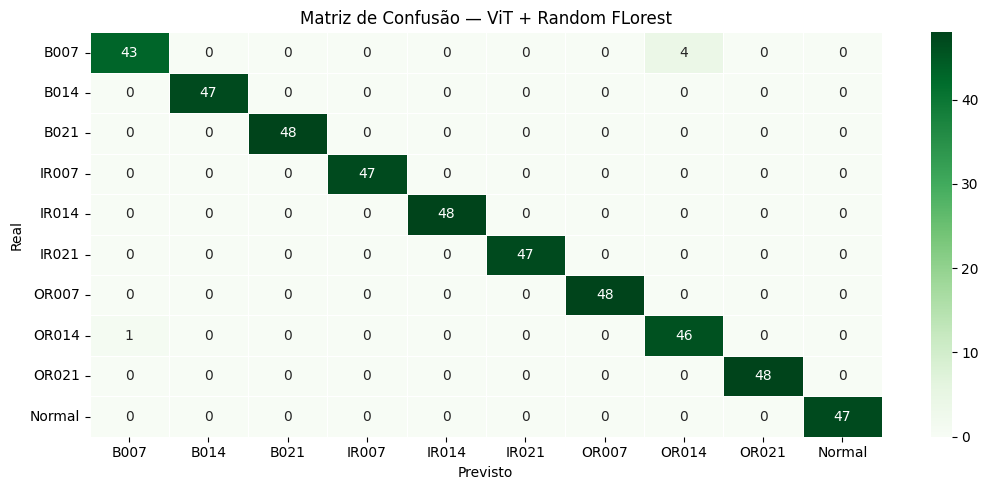

array([[43,  0,  0,  0,  0,  0,  0,  4,  0,  0],
       [ 0, 47,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 48,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 47,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 48,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 47,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 48,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0, 46,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 48,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 47]])

In [ ]:
res_random_florest = print_metrics(y_test, y_pred_all_rf, f"ViT + Random FLorest")

plot_confusion(y_test, y_pred_all_rf,
               f'Matriz de Confusão — ViT + Random FLorest', cmap='Greens')

## 8. Modelo **5** — ViT + XGBOOST

In [ ]:
from xgboost import XGBClassifier

# --- 4. TREINO DO XGBOOST ---
print("\nTreinando XGBoost sobre as características do ViT...")
xgb_classifier = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softprob',
    random_state=42,
    n_jobs=-1
)
xgb_classifier.fit(X_train_feat, y_train)

# Predições
y_pred_xgb = xgb_classifier.predict(X_test_feat)


Treinando XGBoost sobre as características do ViT...



  ViT + XGBoost
  Accuracy  : 0.9916
  Precision : 0.9922
  Recall    : 0.9916
  F1 Score  : 0.9915


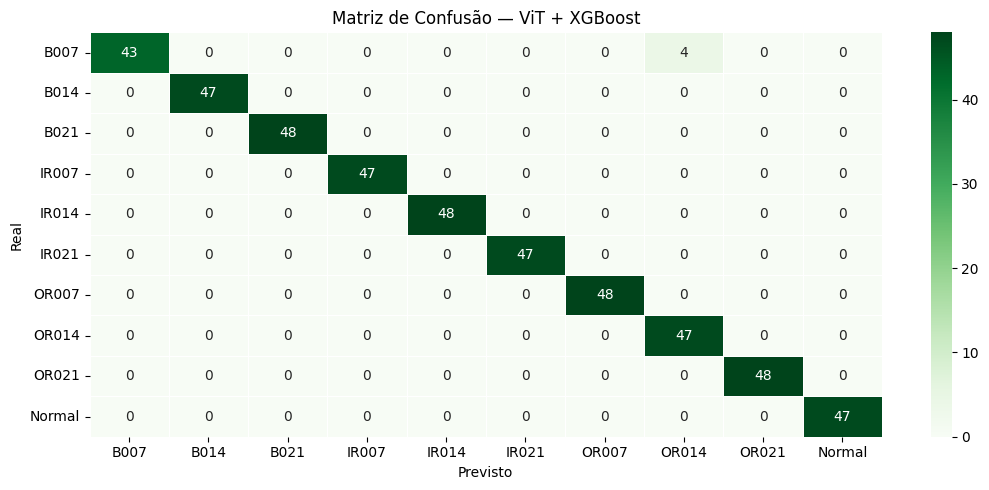

array([[43,  0,  0,  0,  0,  0,  0,  4,  0,  0],
       [ 0, 47,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 48,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 47,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 48,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 47,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 48,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 47,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 48,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 47]])

In [ ]:
res_xgb = print_metrics(y_test, y_pred_xgb, f"ViT + XGBoost")

plot_confusion(y_test, y_pred_xgb,
               f'Matriz de Confusão — ViT + XGBoost', cmap='Greens')

## 9. Modelo **6** — ViT + SMV

In [ ]:
from sklearn.svm import SVC

# Treino do SVM
print("Treinando SVM (Kernel RBF)...")
clf_svm = SVC(kernel='rbf', C=10, gamma='scale')
clf_svm.fit(X_train_feat, y_train)

# Avaliação
y_pred_svm = clf_svm.predict(X_test_feat)

Treinando SVM (Kernel RBF)...



  ViT + SVM
  Accuracy  : 0.9895
  Precision : 0.9898
  Recall    : 0.9895
  F1 Score  : 0.9894


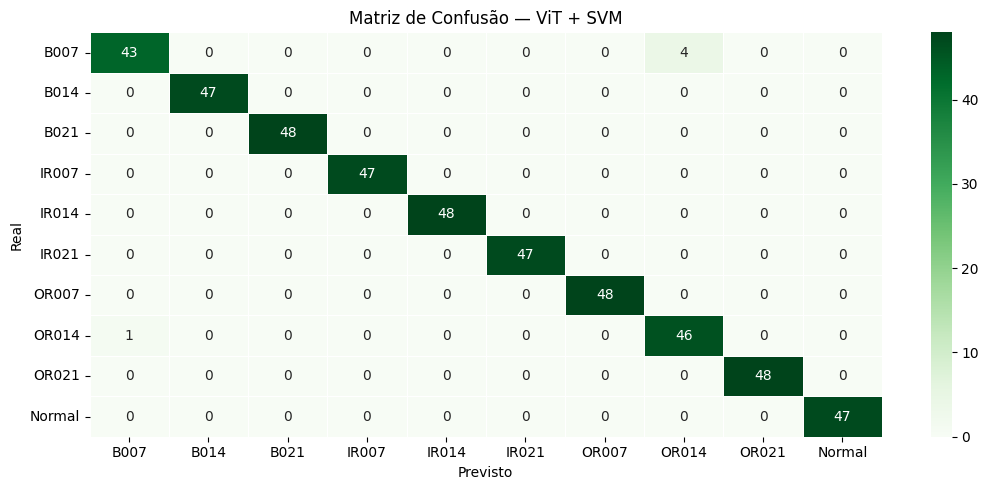

array([[43,  0,  0,  0,  0,  0,  0,  4,  0,  0],
       [ 0, 47,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 48,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 47,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 48,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 47,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 48,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0, 46,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 48,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 47]])

In [ ]:
res_svm = print_metrics(y_test, y_pred_svm, f"ViT + SVM")

plot_confusion(y_test, y_pred_svm,
               f'Matriz de Confusão — ViT + SVM', cmap='Greens')

## 10. Modelo **7** — ViT + LIGHTGBM

In [ ]:
from lightgbm import LGBMClassifier

# --- 2. TREINO DO LIGHTGBM ---
print("\nTreinando LightGBM sobre as características do ViT...")
lgbm_classifier = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=31,
    objective='multiclass',
    random_state=42,
    n_jobs=-1,
    importance_type='gain'
)

lgbm_classifier.fit(X_train_feat, y_train)

# Predições
y_pred_lgbm = lgbm_classifier.predict(X_test_feat)


Treinando LightGBM sobre as características do ViT...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 65280
[LightGBM] [Info] Number of data points in the train set: 5685, number of used features: 256
[LightGBM] [Info] Start training from score -2.299950
[LightGBM] [Info] Start training from score -2.299950
[LightGBM] [Info] Start training from score -2.305227
[LightGBM] [Info] Start training from score -2.299950
[LightGBM] [Info] Start training from score -2.299950
[LightGBM] [Info] Start training from score -2.305227
[LightGBM] [Info] Start training from score -2.305227
[LightGBM] [Info] Start training from score -2.305227
[LightGBM] [Info] Start training from score -2.299950
[LightGBM] [Info] Start training from score -2.305227
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  ViT + LightGBM
  Accuracy  : 0.9895
  Precision : 0.9898
  Recall    : 0.9895
  F1 Score  : 0.9894


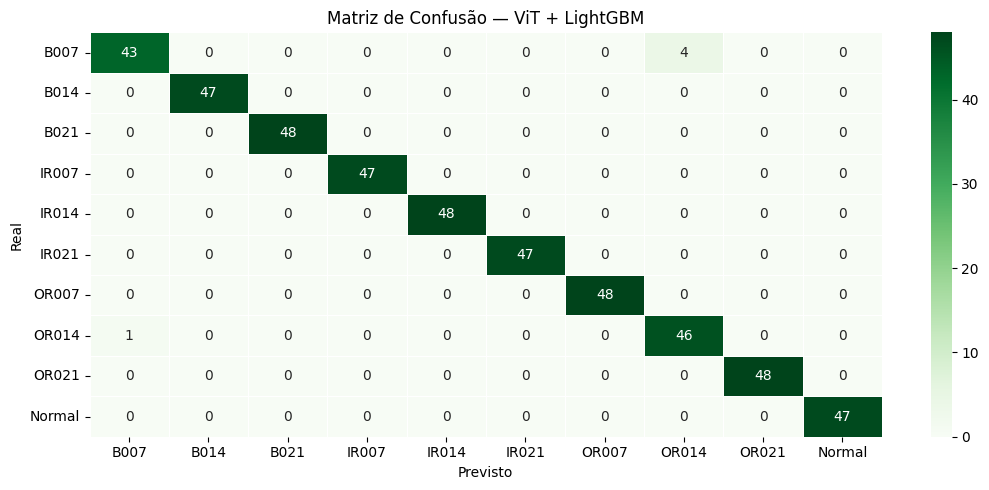

array([[43,  0,  0,  0,  0,  0,  0,  4,  0,  0],
       [ 0, 47,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 48,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 47,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 48,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 47,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 48,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0, 46,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 48,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 47]])

In [ ]:
res_lgbm = print_metrics(y_test, y_pred_lgbm, f"ViT + LightGBM")

plot_confusion(y_test, y_pred_lgbm,
               f'Matriz de Confusão — ViT + LightGBM', cmap='Greens')

## 11. Modelo **8** — ViT + LSTM

In [ ]:
def build_lstm_comparison_model(extractor_model):
    extractor_model.trainable = False
    inputs = extractor_model.input # O input original (2048, 1)
    features = extractor_model.output # A saída do extrator (256,))

    x = layers.Reshape((1, 256), name="reshape_lstm")(features)
    x = layers.LSTM(64, return_sequences=True, name="lstm_layer_1")(x)
    x = layers.Dropout(0.2, name="dropout_lstm_1")(x)
    x = layers.LSTM(64, name="lstm_layer_2")(x)
    x = layers.Dropout(0.2, name="dropout_lstm_2")(x)
    x = layers.Dense(128, activation='gelu', name="dense_classification_lstm")(x)
    x = layers.Dropout(0.3, name="dropout_final")(x)

    outputs = layers.Dense(num_classes, activation='softmax', name="output_softmax_lstm")(x)

    model = keras.Model(inputs, outputs, name="LSTM_Model")
    return model


lstm_model = build_lstm_comparison_model(extrator)
lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=10,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        mode='min',
        factor=0.5,
        patience=5,
        min_lr=1e-5
    )
]

history_lstm = lstm_model.fit(
    X_train_norm,
    y_train,
    epochs=150,
    batch_size=32,
    shuffle=True,
    validation_split=0.15,
    callbacks=callbacks
)

class_logits_lstm = lstm_model.predict(X_test_norm)
y_pred_all_lstm = tf.argmax(class_logits_lstm, axis=1).numpy()

Epoch 1/150
151/151 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8911 - loss: 1.0026 - val_accuracy: 0.9859 - val_loss: 0.0579 - learning_rate: 5.0000e-04
Epoch 2/150
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9948 - loss: 0.0432 - val_accuracy: 0.9883 - val_loss: 0.0337 - learning_rate: 5.0000e-04
Epoch 3/150
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9957 - loss: 0.0231 - val_accuracy: 0.9918 - val_loss: 0.0216 - learning_rate: 5.0000e-04
Epoch 4/150
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9963 - loss: 0.0168 - val_accuracy: 0.9965 - val_loss: 0.0122 - learning_rate: 5.0000e-04
Epoch 5/150
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9952 - loss: 0.0156 - val_accuracy: 0.9894 - val_loss: 0.0182 - learning_rate: 5.0000e-04
Epoch 6/150
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9963 - loss: 0.0129 - val_accuracy: 0.9883 - val_loss: 0.0157 - learning_rate: 5.0000e-04
Epoch 7/150
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step -


  ViT + LSTM
  Accuracy  : 0.9895
  Precision : 0.9898
  Recall    : 0.9895
  F1 Score  : 0.9894


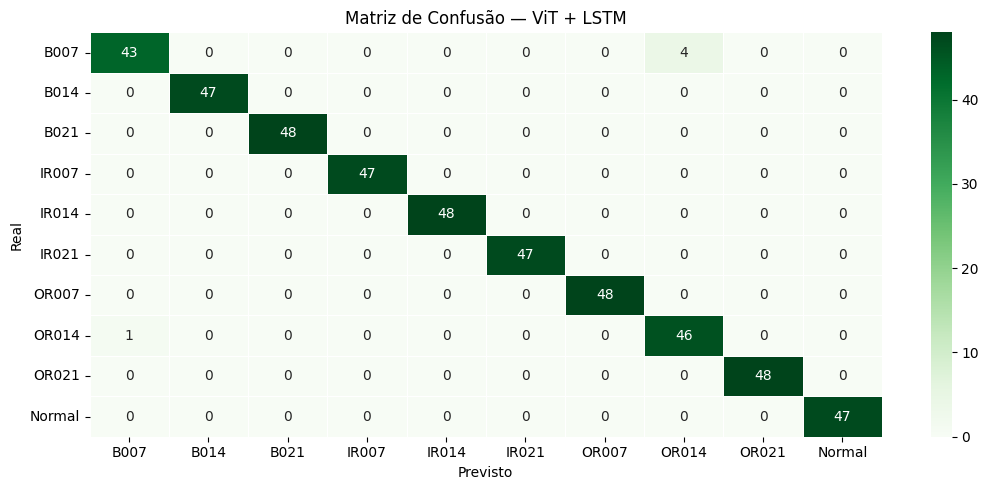

array([[43,  0,  0,  0,  0,  0,  0,  4,  0,  0],
       [ 0, 47,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 48,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 47,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 48,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 47,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 48,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0, 46,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 48,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 47]])

In [ ]:
res_lstm = print_metrics(y_test, y_pred_all_lstm, f"ViT + LSTM")

plot_confusion(y_test, y_pred_all_lstm,
               f'Matriz de Confusão — ViT + LSTM', cmap='Greens')

## 12. Modelo **9** — ViT + GRU

In [ ]:
def build_gru_comparison_model(extractor_model):
    extractor_model.trainable = False
    inputs = extractor_model.input # O input original (2048, 1)
    features = extractor_model.output # A saída do extrator (256,))

    x = layers.Reshape((1, 256), name="reshape_gru")(features)
    x = layers.GRU(64, return_sequences=True, name="gru_layer_1")(x)
    x = layers.Dropout(0.2, name="dropout_gru_1")(x)
    x = layers.GRU(64, name="gru_layer_2")(x)
    x = layers.Dropout(0.2, name="dropout_gru_2")(x)
    x = layers.Dense(128, activation='gelu', name="dense_classification_gru")(x)
    x = layers.Dropout(0.3, name="dropout_final")(x)

    outputs = layers.Dense(num_classes, activation='softmax', name="output_softmax_gru")(x)

    model = keras.Model(inputs, outputs, name="GRU_Model")
    return model

gru_model = build_gru_comparison_model(extrator)
gru_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=10,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        mode='min',
        factor=0.5,
        patience=5,
        min_lr=1e-5
    )
]

# Treinamento
history_gru = gru_model.fit(
    X_train_norm, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks
)

class_logits_gru = gru_model.predict(X_test_norm)
y_pred_all_gru = tf.argmax(class_logits_gru, axis=1).numpy()

Epoch 1/150
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9973 - loss: 0.0102 - val_accuracy: 0.9965 - val_loss: 0.0095 - learning_rate: 1.2500e-04
Epoch 2/150
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9967 - loss: 0.0101 - val_accuracy: 0.9953 - val_loss: 0.0119 - learning_rate: 1.2500e-04
Epoch 3/150
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9967 - loss: 0.0092 - val_accuracy: 0.9977 - val_loss: 0.0065 - learning_rate: 1.2500e-04
Epoch 4/150
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9981 - loss: 0.0068 - val_accuracy: 0.9965 - val_loss: 0.0092 - learning_rate: 1.2500e-04
Epoch 5/150
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9975 - loss: 0.0077 - val_accuracy: 0.9953 - val_loss: 0.0104 - learning_rate: 1.2500e-04
Epoch 6/150
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9973 - loss: 0.0097 - val_accuracy: 0.9965 - val_loss: 0.0098 - learning_rate: 1.2500e-04
Epoch 7/150
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - 


  ViT + GRU
  Accuracy  : 0.9895
  Precision : 0.9898
  Recall    : 0.9895
  F1 Score  : 0.9894


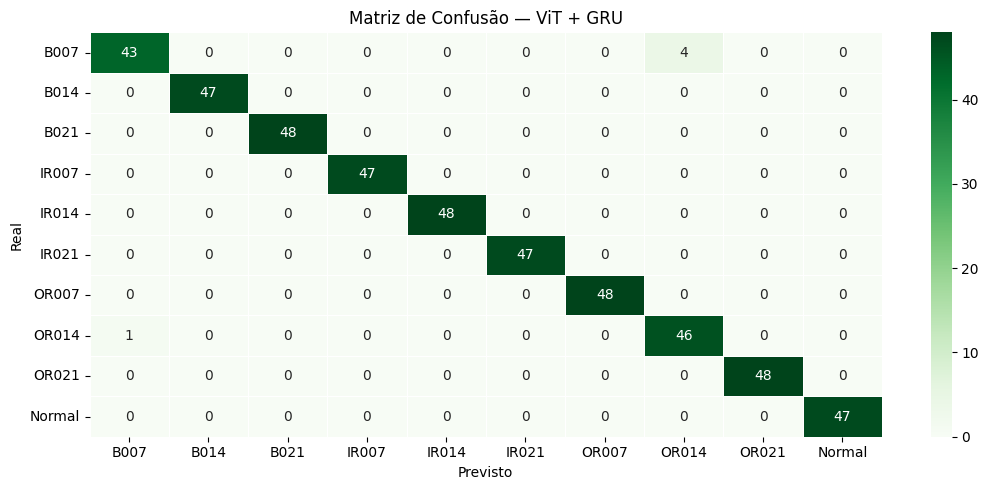

array([[43,  0,  0,  0,  0,  0,  0,  4,  0,  0],
       [ 0, 47,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 48,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 47,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 48,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 47,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 48,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0, 46,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 48,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 47]])

In [ ]:
res_gru = print_metrics(y_test, y_pred_all_gru, f"ViT + GRU")

plot_confusion(y_test, y_pred_all_gru,
               f'Matriz de Confusão — ViT + GRU', cmap='Greens')